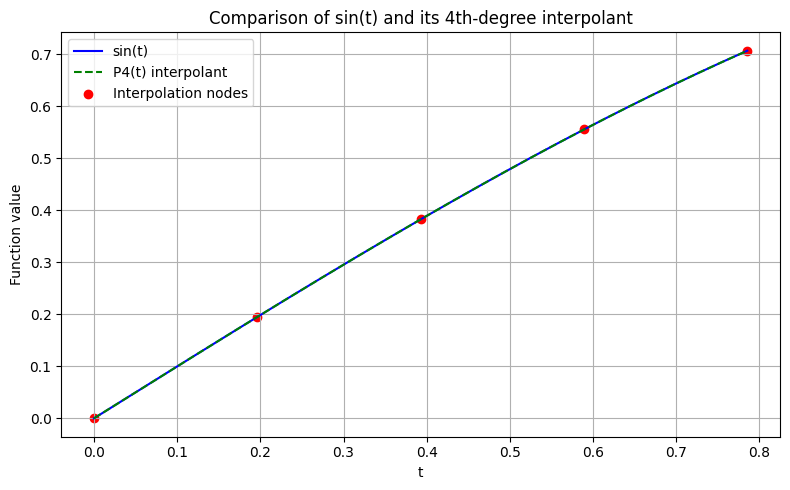

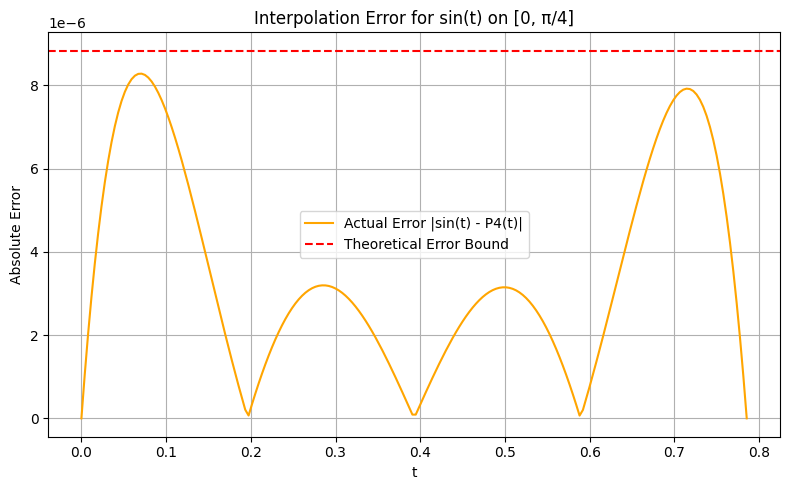

Theoretical Error Bound (degree 4): 8.83e-06
Actual Max Error (degree 4): 8.28e-06
Required degree to achieve error < 1e-16: 13
Required number of interpolation points: 14


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# Step 1: 设置插值区间和节点数（五个等距点 → 四次多项式）
# Step 1: Define interpolation interval and number of nodes (5 equally spaced nodes → 4th-degree polynomial)
a, b = 0, np.pi / 4
n = 4
x_nodes = np.linspace(a, b, n + 1)
y_nodes = np.sin(x_nodes)

# Step 2: 使用 numpy.polyfit 拟合多项式（返回最高次项在前的系数）
# Step 2: Use numpy.polyfit to fit polynomial (returns coefficients in descending powers)
coeffs = np.polyfit(x_nodes, y_nodes, deg=n)
p4 = np.poly1d(coeffs)

# Step 3: 理论误差上界估计
# Step 3: Estimate theoretical error bound
M = 1   
# f⁽⁵⁾(t) = cos(t)，on interval [0, π/4] max value is cos(0) = 1
t_vals = np.linspace(a, b, 1000)
# 估计 max |(t - x0)...(t - xn)| 通过在区间上均匀采样
product_term = np.abs(np.prod([t_vals - xi for xi in x_nodes], axis=0))
max_product = np.max(product_term)
error_bound = M / factorial(n + 1) * max_product

# Step 4: 验证误差实际值
# Step 4: Validate actual interpolation error
t_test = np.linspace(a, b, 200)
f_true = np.sin(t_test)
f_interp = p4(t_test)
true_error = np.abs(f_true - f_interp)
max_true_error = np.max(true_error)

# Step 5: 反过来估算达到误差 1e-16 所需插值点数
# Step 5: Estimate required polynomial degree to achieve error < 1e-16
target_error = 1e-16
h = (b - a) / 2  # 用于最大值估计 (b-a)/2
min_n = None
for k in range(5, 100):
    bound = (h ** (k + 1)) / factorial(k + 1)
    if bound < target_error:
        min_n = k
        break

# Step 6.1: 画出插值函数 P4 和原函数 sin(t) 的对比图
# Step 6.1: Plot comparison of interpolation P4 and original function sin(t)
plt.figure(figsize=(8, 5))
plt.plot(t_test, f_true, label='sin(t)', color='blue')
plt.plot(t_test, f_interp, label='P4(t) interpolant', color='green', linestyle='--')
plt.scatter(x_nodes, y_nodes, color='red', label='Interpolation nodes')
plt.title("Comparison of sin(t) and its 4th-degree interpolant")
plt.xlabel("t")
plt.ylabel("Function value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6.2: 绘图：实际误差 vs 理论误差上界
# Step 6.2: Plot actual error vs theoretical error bound
plt.figure(figsize=(8, 5))
plt.plot(t_test, true_error, label='Actual Error |sin(t) - P4(t)|', color='orange')
plt.axhline(error_bound, color='red', linestyle='--', label='Theoretical Error Bound')
plt.title("Interpolation Error for sin(t) on [0, π/4]")
plt.xlabel("t")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: 打印关键结果
# Step 7: Print key results
print(f"Theoretical Error Bound (degree 4): {error_bound:.2e}")
print(f"Actual Max Error (degree 4): {max_true_error:.2e}")
print(f"Required degree to achieve error < 1e-16: {min_n}")
print(f"Required number of interpolation points: {min_n + 1 if min_n else 'Not Found'}")
